# SportIQ — prediction history

Daily results and a queryable record of every call the models have made.

**Run this with the `SportIQ (backend venv)` kernel.** Anaconda's base environment has pandas and
matplotlib but no database driver, so the project venv is registered as a kernel instead of
adding a dependency:

    backend/.venv/Scripts/python -m ipykernel install --user --name sportiq --display-name "SportIQ (backend venv)"

---

## What this measures, and what it deliberately does not

`docs/history-metrics-spec.md` separates two questions that are easy to conflate. This notebook
keeps them apart.

**Model skill — measured here.** Are the probabilities any good? Calibration, Brier, reliability
buckets, accuracy against each population's own baseline. Needs no odds and no record of what was
displayed, so it works over all history.

**Product skill — only from 2026-08-10.** Were the picks we *showed* worth backing? That needs the
pick as displayed, which lives in `pick_snapshots` and did not exist before that date. Recomputing
it from today's odds and today's guards would measure a different product than users saw, so the
CLV section is scoped to snapshots and says so.

## Population rules, applied everywhere below

| Filter | Value | Why |
|---|---|---|
| `predictions.kind` | `PRE_MATCH` only | A retrodiction is produced after the result is known. Legitimate for the feed, never evidence of skill. |
| `fixtures.status` | `completed` | Nothing else has a result. |
| `outcomes` | row must exist | The graded truth. |
| `fixture_live_state.result_type` | `NULL` | Excludes voids — a tennis retirement has no bettable result and most books void the bet. |

`UNKNOWN`-provenance rows are **counted and reported, never silently dropped or included**. They
are rows whose provenance was destroyed by regeneration; a timestamp cannot recover it.

Grading is imported from `app.history.router` rather than reimplemented, so this notebook and the
live endpoint cannot drift apart.

In [1]:
import asyncio
import math
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path.cwd()
while not (REPO / "backend").is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
BACKEND = REPO / "backend"
sys.path.insert(0, str(BACKEND))

from dotenv import load_dotenv

load_dotenv(BACKEND / ".env")

# Imported, not reimplemented. A notebook that computes its own Wilson interval will eventually
# disagree with the endpoint and there will be no way to tell which one moved.
from app.history.router import (  # noqa: E402
    ACCURACY_EDGE_THRESHOLD,
    MIN_REPORTABLE_N,
    _detectable_effect,
    _wilson_interval,
)

plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
OK, BAD, NEUTRAL, ACCENT = "#2e7d32", "#c62828", "#9e9e9e", "#1565c0"

print(f"repo        : {REPO}")
print(f"reportable n: {MIN_REPORTABLE_N}   edge threshold: {ACCURACY_EDGE_THRESHOLD:.0%}")

repo        : C:\Users\User\IdeaProjects\SportIQ
reportable n: 93   edge threshold: 3%


## Query parameters

Everything below is driven by these. `None` means "no filter".

In [2]:
SPORT = None          # 'football' | 'tennis' | 'nba' | None for all
LEAGUE = None         # e.g. 'epl', 'atp'
DATE_FROM = None      # 'YYYY-MM-DD' — filters on KICKOFF, not settlement
DATE_TO = None
KIND = "PRE_MATCH"    # 'PRE_MATCH' is the only population that evidences skill.
                      # 'RETRODICTION' is available for inspection; never for a headline.
INCLUDE_VOIDS = False # Voids stay out by default: most books void the bet, so scoring one as a
                      # win or a loss claims a payout the user may never have received.

In [3]:
DSN = os.environ["DATABASE_URL"].replace("+asyncpg", "")

GRADED_SQL = '''
select f.id                as fixture_id,
       f.kickoff_utc,
       o.settled_at,
       s.slug              as sport,
       l.slug              as league,
       ht.name             as home_team,
       at.name             as away_team,
       p.id                as prediction_id,
       p.created_at,
       p.model_version,
       p.kind::text        as kind,
       p.home_prob, p.draw_prob, p.away_prob,
       p.confidence_tier::text as confidence_tier,
       p.feature_completeness,
       p.xg_home, p.xg_away, p.corners_xg_home, p.corners_xg_away,
       o.result::text      as result,
       o.home_score, o.away_score,
       ls.result_type::text as result_type,
       ls.home_corners, ls.away_corners
from outcomes o
join fixtures f  on f.id = o.fixture_id
join predictions p on p.fixture_id = f.id
join sports s    on s.id = f.sport_id
join leagues l   on l.id = f.league_id
join teams ht    on ht.id = f.home_team_id
join teams at    on at.id = f.away_team_id
left join fixture_live_state ls on ls.fixture_id = f.id
'''

SNAPSHOT_SQL = '''
select ps.*, f.kickoff_utc, s.slug as sport, l.slug as league,
       o.result::text as result, o.home_score, o.away_score,
       ls.result_type::text as result_type
from pick_snapshots ps
join fixtures f on f.id = ps.fixture_id
join sports s   on s.id = f.sport_id
join leagues l  on l.id = f.league_id
left join outcomes o on o.fixture_id = f.id
left join fixture_live_state ls on ls.fixture_id = f.id
'''

ODDS_SQL = '''
select o.fixture_id, o.bookmaker, o.market::text as market, o.line,
       o.home_odds, o.draw_odds, o.away_odds, o.over_odds, o.under_odds, o.updated_at
from odds o
join fixtures f on f.id = o.fixture_id
join pick_snapshots ps on ps.fixture_id = f.id
group by o.fixture_id, o.bookmaker, o.market, o.line, o.home_odds, o.draw_odds,
         o.away_odds, o.over_odds, o.under_odds, o.updated_at
'''


async def fetch(sql):
    import asyncpg

    conn = await asyncpg.connect(DSN)
    try:
        return pd.DataFrame([dict(r) for r in await conn.fetch(sql)])
    finally:
        await conn.close()


# Top-level await: ipykernel supports it, so no nest_asyncio and no extra dependency. Everything
# is pulled once into DataFrames and every section below is pure pandas — one round trip, and the
# analysis stays reproducible even if the database moves on mid-session.
raw_graded = await fetch(GRADED_SQL)
raw_snaps = await fetch(SNAPSHOT_SQL)
raw_odds = await fetch(ODDS_SQL)
print(f"loaded: {len(raw_graded)} graded rows, {len(raw_snaps)} snapshots, {len(raw_odds)} odds rows")

loaded: 819 graded rows, 57 snapshots, 4117 odds rows


In [4]:
def predicted_outcome(row):
    '''The model's 1X2 call — argmax of home/draw/away.

    draw_prob is None for two-outcome sports (tennis, NBA), where a draw is not a possible result
    at all, so it is excluded rather than treated as a zero-probability option. Same rule as
    app/history/router.py:_predicted_outcome.'''
    options = [("home", row.home_prob), ("away", row.away_prob)]
    if pd.notna(row.draw_prob):
        options.append(("draw", row.draw_prob))
    return max(options, key=lambda kv: kv[1])[0]


RESULT_BY_OUTCOME = {"home": "HOME_WIN", "draw": "DRAW", "away": "AWAY_WIN"}


DEDUP_REPORT = {}


def dedup(df):
    '''One row per (fixture, kind) — the final forecast, not every revision of it.

    run_predictions APPENDS a prediction rather than replacing one, so a fixture re-predicted as
    its features changed carries a series. Consuming that series as though each row were an
    independent event weights a fixture by how often it happened to be re-predicted. Measured
    2026-08-13: 143 settled football pre-match rows sat on 63 fixtures, one carrying 25, and the
    accuracy moved 0.5524 -> 0.3651 once each fixture counted once.

    Prefer a row created BEFORE kickoff, then the latest of those. created_at alone is not
    enough — regeneration reset it on 91 football rows to after their own kickoffs. Identical
    ordering to app/history/router.py:_representative_prediction_ids, so this notebook and the
    endpoint cannot report different populations.'''
    before = df.copy()
    before["_pre"] = (before["created_at"] < before["kickoff_utc"]).astype(int)
    kept = (
        before.sort_values(["_pre", "created_at", "prediction_id"], ascending=[False, False, False])
        .groupby(["fixture_id", "kind"], as_index=False)
        .head(1)
        .drop(columns="_pre")
    )
    DEDUP_REPORT.update(rows_in=len(df), fixtures_out=len(kept), collapsed=len(df) - len(kept))
    return kept


def prepare(df):
    df = df.copy()
    df["kickoff_utc"] = pd.to_datetime(df["kickoff_utc"], utc=True)
    df["created_at"] = pd.to_datetime(df["created_at"], utc=True)
    df = dedup(df)
    df["day"] = df["kickoff_utc"].dt.date
    df["predicted"] = df.apply(predicted_outcome, axis=1)
    df["predicted_prob"] = df.apply(
        lambda r: {"home": r.home_prob, "draw": r.draw_prob, "away": r.away_prob}[r.predicted],
        axis=1,
    )
    df["correct"] = df.apply(
        lambda r: RESULT_BY_OUTCOME[r.predicted] == r.result, axis=1
    ).astype(int)
    return df


def apply_filters(df):
    out = df
    if SPORT:
        out = out[out["sport"] == SPORT]
    if LEAGUE:
        out = out[out["league"] == LEAGUE]
    if DATE_FROM:
        out = out[out["day"] >= pd.Timestamp(DATE_FROM).date()]
    if DATE_TO:
        out = out[out["day"] <= pd.Timestamp(DATE_TO).date()]
    return out


all_graded = prepare(raw_graded)
excluded_void = int((all_graded["result_type"].notna()).sum())
population = all_graded if INCLUDE_VOIDS else all_graded[all_graded["result_type"].isna()]
by_kind = population["kind"].value_counts().to_dict()
graded = apply_filters(population[population["kind"] == KIND])

print(f"collapsed {DEDUP_REPORT['collapsed']} duplicate prediction rows "
      f"({DEDUP_REPORT['rows_in']} rows -> {DEDUP_REPORT['fixtures_out']} fixture/kind pairs)")
print(f"kind breakdown (all sports): {by_kind}")
print(f"excluded as VOID           : {excluded_void}")
print(f"population after filters   : {len(graded)} rows, kind={KIND}")

collapsed 90 duplicate prediction rows (819 rows -> 729 fixture/kind pairs)
kind breakdown (all sports): {'UNKNOWN': 581, 'PRE_MATCH': 138}
excluded as VOID           : 10
population after filters   : 138 rows, kind=PRE_MATCH


## 1. Coverage — what can honestly be said at all

**One prediction per fixture.** `run_predictions` appends a row rather than replacing one, so a
fixture re-predicted as its features changed carries a whole series — up to 25 rows for a single
football fixture. Counting those as independent events weights a fixture by how often it happened
to be re-predicted, which moved the reported football accuracy from **0.5524 to 0.3651**. This
notebook found that defect in the live endpoint, and both now collapse to the last forecast made
before kickoff, using identical ordering.

`n`, the 95% Wilson interval and the **minimum detectable effect** are printed together
deliberately. An accuracy without them reads as though it settled a question it cannot. A sample
whose detectable effect exceeds the edge we believe in cannot confirm *or* refute that edge, and
that is a different statement from "not enough rows to print".

In [5]:
def summarise(df, label):
    n = len(df)
    if n == 0:
        return {"population": label, "n": 0}
    correct = int(df["correct"].sum())
    acc = correct / n
    lo, hi = _wilson_interval(correct, n)
    mde = _detectable_effect(acc, n)
    # Each population against ITS OWN majority-class baseline. A single pooled baseline flatters
    # some leagues and punishes others, because home advantage genuinely differs between them.
    baseline = df["result"].value_counts(normalize=True).max()
    return {
        "population": label,
        "n": n,
        "accuracy": round(acc, 4),
        "ci_low": round(lo, 4),
        "ci_high": round(hi, 4),
        "baseline": round(baseline, 4),
        "gap_pp": round((acc - baseline) * 100, 2),
        "detectable_pp": round(mde * 100, 2),
        "reportable": n >= MIN_REPORTABLE_N,
        "conclusive": mde <= ACCURACY_EDGE_THRESHOLD,
    }


rows = [summarise(graded, "ALL (filtered)")]
rows += [summarise(g, f"sport={s}") for s, g in graded.groupby("sport")]
coverage = pd.DataFrame(rows)
display(coverage)

if graded["sport"].nunique() > 1:
    print("NOTE: the ALL row pools sports. Its n is real, but its baseline and gap are NOT — a "
          "majority class spanning football and tennis describes no game anybody plays. Read the "
          "per-sport rows for anything comparative.")
    print()

unreportable = coverage[(coverage["n"] > 0) & (~coverage["reportable"])]["population"].tolist()
inconclusive = coverage[(coverage["n"] > 0) & (~coverage["conclusive"])]["population"].tolist()
print(f"\nbelow the reportable floor (n<{MIN_REPORTABLE_N}): {unreportable or 'none'}")
print(f"cannot settle a {ACCURACY_EDGE_THRESHOLD:.0%} edge either way : {inconclusive or 'none'}")
print(f"\nUNKNOWN-provenance rows excluded from every metric above: "
      f"{by_kind.get('UNKNOWN', 0)} (counted, not hidden)")

,population,n,accuracy,ci_low,ci_high,baseline,gap_pp,detectable_pp,reportable,conclusive
0,ALL (filtered),138,0.5217,0.4389,0.6034,0.5145,0.72,10.58,True,False
1,sport=football,63,0.3651,0.2572,0.4885,0.4286,-6.35,15.09,False,False
2,sport=tennis,75,0.6533,0.5405,0.7512,0.5867,6.67,13.67,False,False


NOTE: the ALL row pools sports. Its n is real, but its baseline and gap are NOT — a majority class spanning football and tennis describes no game anybody plays. Read the per-sport rows for anything comparative.


below the reportable floor (n<93): ['sport=football', 'sport=tennis']
cannot settle a 3% edge either way : ['ALL (filtered)', 'sport=football', 'sport=tennis']

UNKNOWN-provenance rows excluded from every metric above: 581 (counted, not hidden)


## 2. Daily results

The chart the day-to-day question asks for — but read the second panel with the error bars in
mind. At roughly ten settled fixtures a day, a single day's accuracy has a confidence interval
tens of points wide, so day-to-day movement is overwhelmingly noise. The bars show volume, which
is real; the points show accuracy, whose uncertainty is drawn rather than left implied.

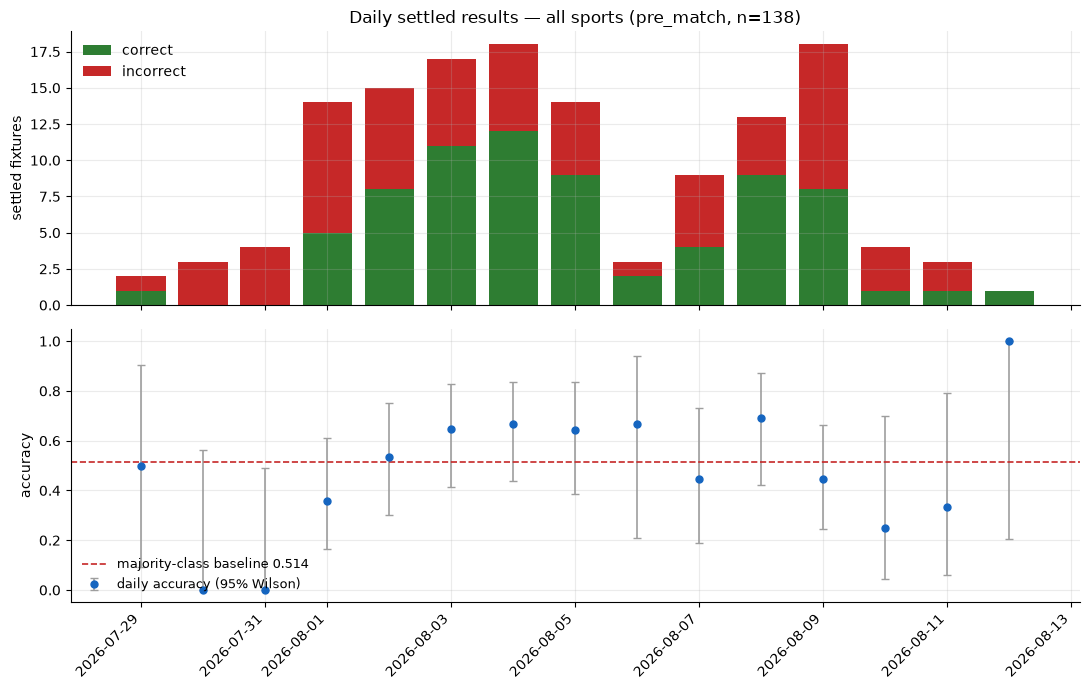

,day,n,correct,accuracy,ci
0,2026-07-29,2,1,0.500000,"[0.09, 0.91]"
1,2026-07-30,3,0,0.000000,"[0.00, 0.56]"
2,2026-07-31,4,0,0.000000,"[0.00, 0.49]"
3,2026-08-01,14,5,0.357143,"[0.16, 0.61]"
4,2026-08-02,15,8,0.533333,"[0.30, 0.75]"
5,2026-08-03,17,11,0.647059,"[0.41, 0.83]"
6,2026-08-04,18,12,0.666667,"[0.44, 0.84]"
7,2026-08-05,14,9,0.642857,"[0.39, 0.84]"
8,2026-08-06,3,2,0.666667,"[0.21, 0.94]"
9,2026-08-07,9,4,0.444444,"[0.19, 0.73]"


In [6]:
def daily_frame(df):
    g = df.groupby("day").agg(n=("correct", "size"), correct=("correct", "sum")).reset_index()
    g["accuracy"] = g["correct"] / g["n"]
    ci = g.apply(lambda r: _wilson_interval(int(r.correct), int(r.n)), axis=1)
    g["ci_low"] = [c[0] for c in ci]
    g["ci_high"] = [c[1] for c in ci]
    return g


if graded.empty:
    print("no rows for the current filters")
else:
    d = daily_frame(graded)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

    ax1.bar(d["day"], d["correct"], color=OK, label="correct")
    ax1.bar(d["day"], d["n"] - d["correct"], bottom=d["correct"], color=BAD, label="incorrect")
    ax1.set_ylabel("settled fixtures")
    ax1.set_title(f"Daily settled results — {SPORT or 'all sports'} ({KIND.lower()}, n={len(graded)})")
    ax1.legend(loc="upper left", frameon=False)

    base = graded["result"].value_counts(normalize=True).max()
    ax2.errorbar(
        d["day"], d["accuracy"],
        yerr=[d["accuracy"] - d["ci_low"], d["ci_high"] - d["accuracy"]],
        fmt="o", color=ACCENT, ecolor=NEUTRAL, elinewidth=1.2, capsize=3, markersize=5,
        label="daily accuracy (95% Wilson)",
    )
    ax2.axhline(base, color=BAD, ls="--", lw=1.2, label=f"majority-class baseline {base:.3f}")
    ax2.set_ylim(-0.05, 1.05)
    ax2.set_ylabel("accuracy")
    ax2.legend(loc="lower left", frameon=False, fontsize=9)
    plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    display(d.assign(**{"ci": d.apply(lambda r: f"[{r.ci_low:.2f}, {r.ci_high:.2f}]", axis=1)})
             [["day", "n", "correct", "accuracy", "ci"]])

### Cumulative accuracy — the same data, read the way it should be

Daily points are noise; the running total is where a real edge would eventually show. The ribbon
is the 95% Wilson interval, which narrows only as `n` grows. **An edge is demonstrated when the
ribbon's lower bound clears the baseline and stays there** — not when a point does.

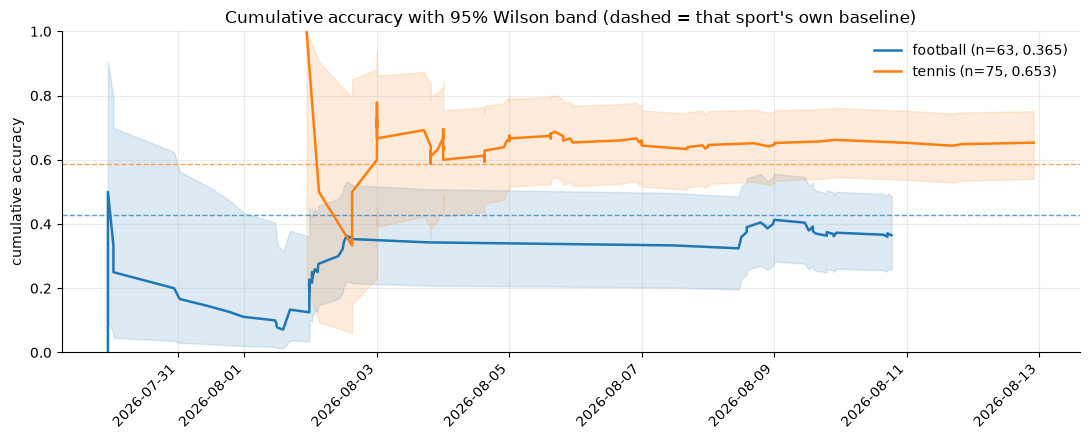

In [7]:
if graded.empty:
    print("no rows for the current filters")
else:
    fig, ax = plt.subplots()
    for sport, g in graded.sort_values("kickoff_utc").groupby("sport"):
        run_n = np.arange(1, len(g) + 1)
        run_correct = g["correct"].cumsum().to_numpy()
        acc = run_correct / run_n
        ci = [_wilson_interval(int(c), int(n)) for c, n in zip(run_correct, run_n)]
        lo, hi = np.array([c[0] for c in ci]), np.array([c[1] for c in ci])
        days = g["kickoff_utc"].to_numpy()
        line, = ax.plot(days, acc, lw=1.8, label=f"{sport} (n={len(g)}, {acc[-1]:.3f})")
        ax.fill_between(days, lo, hi, alpha=0.15, color=line.get_color())
        base = g["result"].value_counts(normalize=True).max()
        ax.axhline(base, ls="--", lw=1, color=line.get_color(), alpha=0.7)
    ax.set_ylim(0, 1)
    ax.set_ylabel("cumulative accuracy")
    ax.set_title("Cumulative accuracy with 95% Wilson band (dashed = that sport's own baseline)")
    ax.legend(frameon=False)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 3. Calibration — is a stated 70% actually 70%?

Accuracy only asks whether the top pick landed. Calibration asks whether the *number* is
trustworthy, which is what a user stakes money against.

Buckets under 20 samples are suppressed rather than plotted: at that size a bucket rate is noise
and drawing it invites reading a wobble as miscalibration.

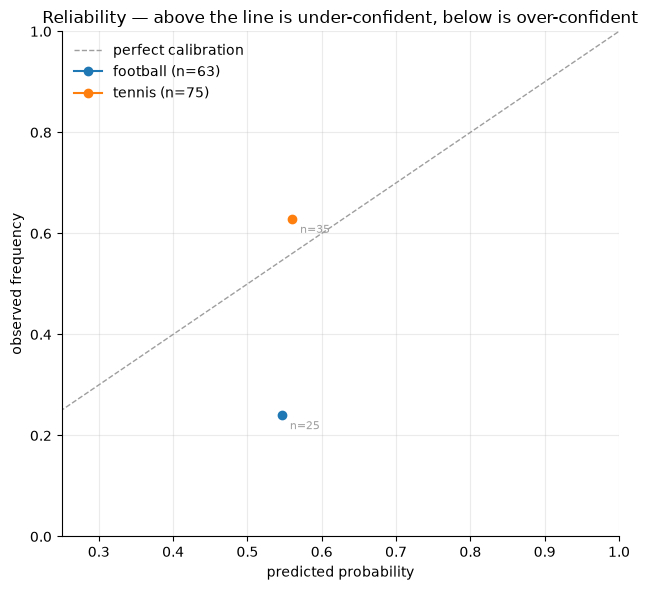


football


,bucket,mid,n,predicted,observed
0,0.5-0.6,0.55,25,0.546,0.24



tennis


,bucket,mid,n,predicted,observed
0,0.5-0.6,0.55,35,0.56,0.629


In [8]:
MIN_BUCKET = 20


def reliability(df, edges=np.arange(0.3, 1.01, 0.1)):
    out = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        sel = df[(df["predicted_prob"] >= lo) & (df["predicted_prob"] < hi)]
        if len(sel) >= MIN_BUCKET:
            out.append({
                "bucket": f"{lo:.1f}-{hi:.1f}",
                "mid": (lo + hi) / 2,
                "n": len(sel),
                "predicted": sel["predicted_prob"].mean(),
                "observed": sel["correct"].mean(),
            })
    return pd.DataFrame(out)


if graded.empty:
    print("no rows")
else:
    fig, ax = plt.subplots(figsize=(6.5, 6))
    ax.plot([0, 1], [0, 1], ls="--", color=NEUTRAL, lw=1, label="perfect calibration")
    any_plotted = False
    for sport, g in graded.groupby("sport"):
        rel = reliability(g)
        if rel.empty:
            print(f"{sport}: every bucket under {MIN_BUCKET} samples — suppressed as noise")
            continue
        any_plotted = True
        ax.plot(rel["predicted"], rel["observed"], "o-", label=f"{sport} (n={len(g)})")
        for _, r in rel.iterrows():
            ax.annotate(f"n={r.n:.0f}", (r["predicted"], r["observed"]),
                        textcoords="offset points", xytext=(6, -10), fontsize=8, color=NEUTRAL)
    ax.set_xlabel("predicted probability")
    ax.set_ylabel("observed frequency")
    ax.set_title("Reliability — above the line is under-confident, below is over-confident")
    ax.set_xlim(0.25, 1.0)
    ax.set_ylim(0, 1.0)
    if any_plotted:
        ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    for sport, g in graded.groupby("sport"):
        rel = reliability(g)
        if not rel.empty:
            print(f"\n{sport}")
            display(rel.round(3))

In [9]:
# Brier over the model's own top pick. Lower is better; it rewards being right AND being
# appropriately unsure, which plain accuracy cannot distinguish.
if not graded.empty:
    brier = (
        graded.assign(sq=(graded["predicted_prob"] - graded["correct"]) ** 2)
        .groupby("sport")
        .agg(n=("sq", "size"), brier=("sq", "mean"),
             mean_predicted=("predicted_prob", "mean"), observed=("correct", "mean"))
        .round(4)
    )
    brier["overconfidence"] = (brier["mean_predicted"] - brier["observed"]).round(4)
    display(brier)
    print("overconfidence > 0 means the model claims more than it delivers, on average")

,n,brier,mean_predicted,observed,overconfidence
sport,,,,,
football,63,0.2670,0.5036,0.3651,0.1385
tennis,75,0.2503,0.6482,0.6533,-0.0051


overconfidence > 0 means the model claims more than it delivers, on average


## 4. The confidence badge

The badge is the most prominent number in the product, and the least examined. It was set from
provisional thresholds that were never validated — so this panel exists to check whether HIGH
actually beats MEDIUM.

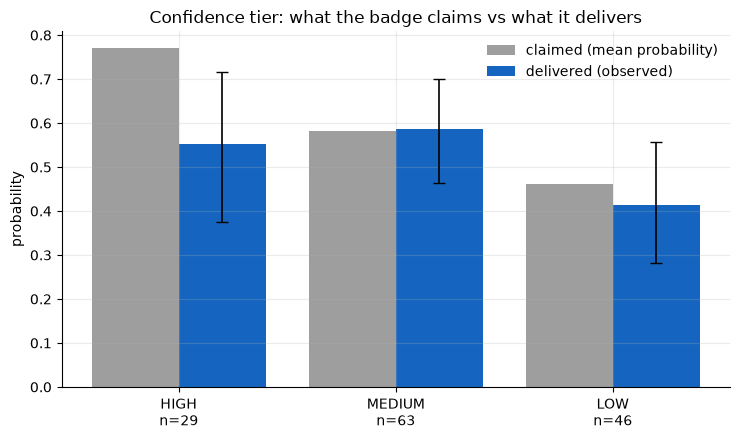

,n,claimed,delivered,ci_low,ci_high
confidence_tier,,,,,
HIGH,29,0.7701,0.5517,0.3755,0.7159
MEDIUM,63,0.5831,0.5873,0.4642,0.7004
LOW,46,0.4624,0.4130,0.2829,0.5566



HIGH (0.552) is delivering BELOW MEDIUM (0.587).
Check the intervals before calling the ordering inverted — if they overlap,
the ordering is unestablished rather than reversed.


In [10]:
if not graded.empty and graded["confidence_tier"].notna().any():
    tier = (
        graded.groupby("confidence_tier")
        .agg(n=("correct", "size"), claimed=("predicted_prob", "mean"),
             delivered=("correct", "mean"))
        .reindex(["HIGH", "MEDIUM", "LOW"]).dropna(how="all")
    )
    ci = [_wilson_interval(int(round(r.delivered * r.n)), int(r.n)) for _, r in tier.iterrows()]
    tier["ci_low"] = [c[0] for c in ci]
    tier["ci_high"] = [c[1] for c in ci]

    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    x = np.arange(len(tier))
    ax.bar(x - 0.2, tier["claimed"], width=0.4, color=NEUTRAL, label="claimed (mean probability)")
    ax.bar(x + 0.2, tier["delivered"], width=0.4, color=ACCENT, label="delivered (observed)")
    ax.errorbar(x + 0.2, tier["delivered"],
                yerr=[tier["delivered"] - tier["ci_low"], tier["ci_high"] - tier["delivered"]],
                fmt="none", ecolor="black", capsize=4, elinewidth=1.2)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{i}\nn={int(r.n)}" for i, r in tier.iterrows()])
    ax.set_ylabel("probability")
    ax.set_title("Confidence tier: what the badge claims vs what it delivers")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()
    display(tier.round(4))
    if {"HIGH", "MEDIUM"}.issubset(tier.index):
        h, m = tier.loc["HIGH"], tier.loc["MEDIUM"]
        if h["delivered"] < m["delivered"]:
            print(f"\nHIGH ({h.delivered:.3f}) is delivering BELOW MEDIUM ({m.delivered:.3f}).")
            print("Check the intervals before calling the ordering inverted — if they overlap,")
            print("the ordering is unestablished rather than reversed.")
else:
    print("no confidence tiers in the current population")

## 5. Feature completeness

The fraction of the model's own feature vector that had a real value at inference time. A
prediction built from a mostly-empty vector is not wrong, but it carries far less information —
and the feed used to render both with identical authority. `MIN_FEATURE_COMPLETENESS = 0.25` is
the hard floor in `app/fixtures/router.py`; mobile dims a badge below 0.35.

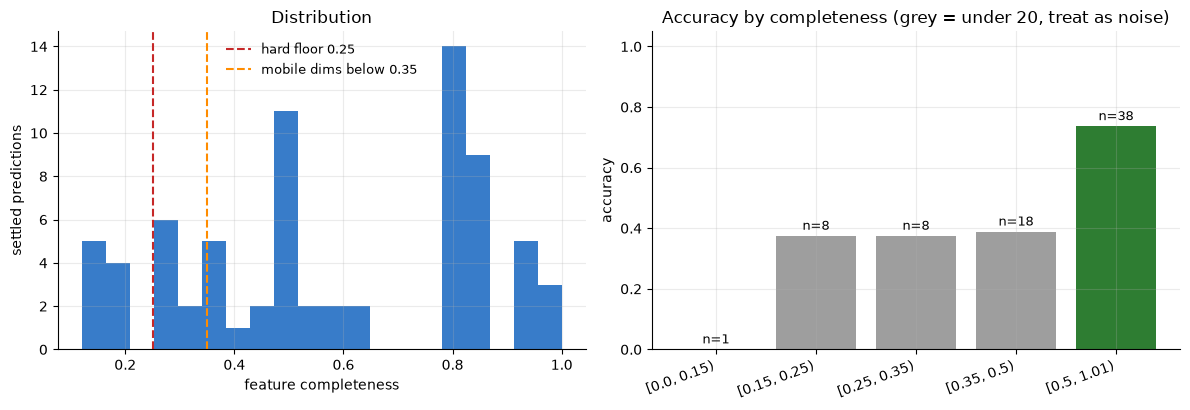

,band,n,accuracy,mean_prob
0,"[0.0, 0.15)",1,0.000,0.569
1,"[0.15, 0.25)",8,0.375,0.466
2,"[0.25, 0.35)",8,0.375,0.606
3,"[0.35, 0.5)",18,0.389,0.617
4,"[0.5, 1.01)",38,0.737,0.651


In [11]:
FLOOR_HARD, FLOOR_DIM = 0.25, 0.35

fc = graded[graded["feature_completeness"].notna()]
if fc.empty:
    print("no feature_completeness recorded in this population (the column is not backfilled — "
          "older predictions genuinely have no measurement)")
else:
    bins = [0, 0.15, 0.25, 0.35, 0.5, 1.01]
    fc = fc.assign(band=pd.cut(fc["feature_completeness"], bins=bins, right=False))
    band = fc.groupby("band", observed=True).agg(
        n=("correct", "size"), accuracy=("correct", "mean"),
        mean_prob=("predicted_prob", "mean")).reset_index()
    band["band"] = band["band"].astype(str)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
    ax1.hist(fc["feature_completeness"], bins=20, color=ACCENT, alpha=0.85)
    ax1.axvline(FLOOR_HARD, color=BAD, ls="--", label=f"hard floor {FLOOR_HARD}")
    ax1.axvline(FLOOR_DIM, color="darkorange", ls="--", label=f"mobile dims below {FLOOR_DIM}")
    ax1.set_xlabel("feature completeness")
    ax1.set_ylabel("settled predictions")
    ax1.set_title("Distribution")
    ax1.legend(frameon=False, fontsize=9)

    ax2.bar(band["band"], band["accuracy"], color=[NEUTRAL if n < MIN_BUCKET else OK
                                                   for n in band["n"]])
    for i, r in band.iterrows():
        ax2.text(i, r["accuracy"] + 0.02, f"n={int(r.n)}", ha="center", fontsize=9)
    ax2.set_ylim(0, 1.05)
    ax2.set_ylabel("accuracy")
    ax2.set_title(f"Accuracy by completeness (grey = under {MIN_BUCKET}, treat as noise)")
    plt.setp(ax2.get_xticklabels(), rotation=20, ha="right")
    plt.tight_layout()
    plt.show()
    display(band.round(3))

## 6. Per league, against each league's own baseline

A pooled number can be carried by one league. Home advantage genuinely differs between
competitions, so each is scored against **its own** majority-class baseline rather than a shared
one — a pooled baseline flatters some and punishes others.

,league,n,accuracy,ci_low,ci_high,baseline,gap_pp,detectable_pp,reportable,conclusive
1,atp,75,0.6533,0.5405,0.7512,0.5867,6.67,13.67,False,False
2,brasileirao,16,0.4375,0.2310,0.6682,0.4375,0.00,30.84,False,False
5,mls,16,0.3750,0.1848,0.6136,0.5000,-12.50,30.10,False,False
3,csl,15,0.3333,0.1518,0.5829,0.6000,-26.67,30.27,False,False
6,scottish_prem,12,0.3333,0.1381,0.6094,0.5000,-16.67,33.84,False,False
0,allsvenskan,2,0.5000,0.0945,0.9055,0.5000,0.00,87.93,False,False
4,liga_i,2,0.0000,0.0000,0.6576,1.0000,-100.00,0.01,False,True


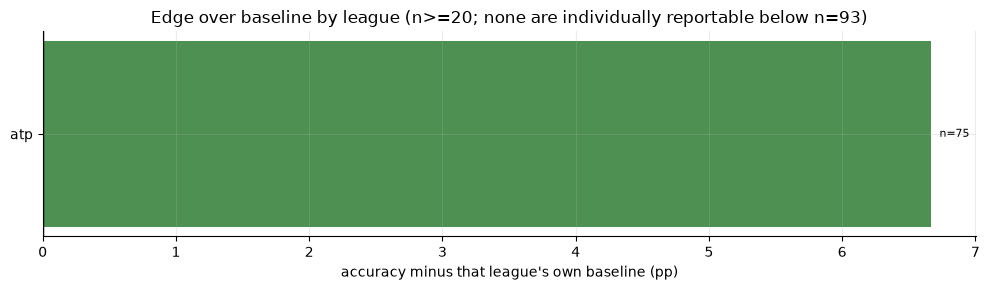

Every per-league cut here is far below the reportable floor. Treat the ordering as a prompt for a question, never as a finding — an earlier per-league table read from live data had two leagues at +26pp and -27pp whose signs both FLIPPED on a proper test set.


In [12]:
if graded.empty:
    print("no rows")
else:
    per_league = (
        pd.DataFrame([summarise(g, lg) for lg, g in graded.groupby("league")])
        .rename(columns={"population": "league"})
        .sort_values("n", ascending=False)
    )
    display(per_league)

    show = per_league[per_league["n"] >= MIN_BUCKET]
    if not show.empty:
        fig, ax = plt.subplots(figsize=(10, max(3, 0.45 * len(show))))
        colors = [OK if g > 0 else BAD for g in show["gap_pp"]]
        ax.barh(show["league"], show["gap_pp"], color=colors, alpha=0.85)
        ax.axvline(0, color="black", lw=1)
        ax.set_xlabel("accuracy minus that league's own baseline (pp)")
        ax.set_title(f"Edge over baseline by league (n>={MIN_BUCKET}; none are individually reportable "
                     f"below n={MIN_REPORTABLE_N})")
        for i, (_, r) in enumerate(show.iterrows()):
            ax.text(r["gap_pp"], i, f"  n={int(r.n)}", va="center", fontsize=8)
        plt.tight_layout()
        plt.show()
    print("Every per-league cut here is far below the reportable floor. Treat the ordering as a "
          "prompt for a question, never as a finding — an earlier per-league table read from live "
          "data had two leagues at +26pp and -27pp whose signs both FLIPPED on a proper test set.")

## 7. Closing line value — product skill, and only from 2026-08-10

CLV is `taken / closing - 1`: did the price we showed beat where the market finished? It is the
one measure that separates a model with an edge from one that merely backs short favourites.

Two things bound it. Snapshots start on 2026-08-10, so nothing before that can be measured at all.
And the **control matters**: some drift is systematic rather than anything about the model, so the
side we did *not* favour is measured alongside. The control is not clean — for a 3-way market it
is usually the longer, more volatile price — so read the gap directionally, not precisely.

,n,mean_clv,median_clv
sport,,,
tennis,5,-0.2836,-0.34


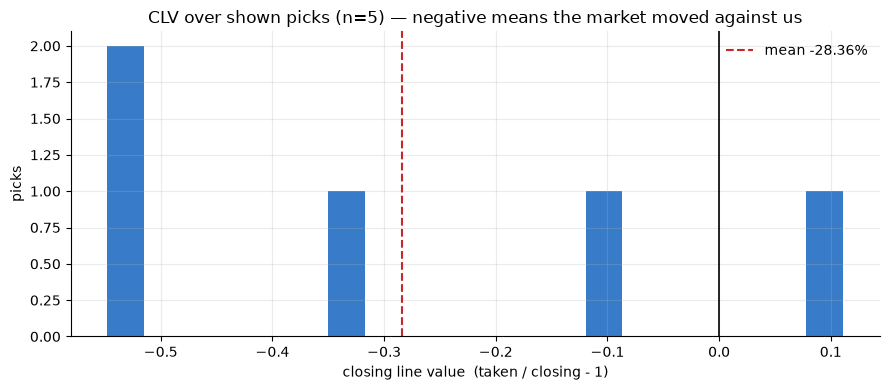

n=5. Far too few to conclude anything; this panel exists so the number accumulates in the open rather than being computed once, later, from memory.


In [13]:
SELECTION_COLUMN = {
    ("h2h", "home"): "home_odds", ("h2h", "draw"): "draw_odds", ("h2h", "away"): "away_odds",
    ("double_chance", "home_or_draw"): "home_odds",
    ("double_chance", "away_or_draw"): "away_odds",
    ("goals_total", "over"): "over_odds", ("goals_total", "under"): "under_odds",
    ("corners_total", "over"): "over_odds", ("corners_total", "under"): "under_odds",
}
MARKET_ENUM = {"h2h": "H2H", "double_chance": "DOUBLE_CHANCE",
               "goals_total": "GOALS_TOTAL", "corners_total": "CORNERS_TOTAL"}

if raw_snaps.empty:
    print("no pick snapshots yet")
else:
    snaps = raw_snaps.copy()
    snaps["kickoff_utc"] = pd.to_datetime(snaps["kickoff_utc"], utc=True)
    snaps["captured_at"] = pd.to_datetime(snaps["captured_at"], utc=True)
    odds = raw_odds.copy()
    odds["updated_at"] = pd.to_datetime(odds["updated_at"], utc=True)

    def closing_price(snap, selection):
        col = SELECTION_COLUMN.get((snap["market"], selection))
        if col is None:
            return None
        cand = odds[(odds["fixture_id"] == snap["fixture_id"])
                    & (odds["market"] == MARKET_ENUM.get(snap["market"]))
                    & (odds["updated_at"] <= snap["kickoff_utc"])]
        if pd.notna(snap.get("line")):
            cand = cand[cand["line"] == snap["line"]]
        cand = cand[cand[col].notna()]
        if cand.empty:
            return None
        # The LAST price before kickoff, per book, then the best of them — matching how the feed
        # picks a price. Taking a mean across books would invent a line no user could have taken.
        latest = cand.sort_values("updated_at").groupby("bookmaker").tail(1)
        return float(latest[col].max())

    OPPOSITE = {"home": "away", "away": "home", "over": "under", "under": "over",
                "home_or_draw": "away_or_draw", "away_or_draw": "home_or_draw"}

    rows = []
    for _, s in snaps.iterrows():
        if pd.isna(s["odds"]) or pd.isna(s["result"]):
            continue
        close = closing_price(s, s["selection"])
        ctrl_sel = OPPOSITE.get(s["selection"])
        ctrl_taken = closing_price(s, ctrl_sel) if ctrl_sel else None
        if close and close > 0:
            rows.append({
                "sport": s["sport"], "market": s["market"], "selection": s["selection"],
                "taken": s["odds"], "closing": close,
                "clv": s["odds"] / close - 1,
                "captured_at": s["captured_at"],
            })
    clv = pd.DataFrame(rows)
    if clv.empty:
        print(f"{len(snaps)} snapshots, but none could be matched to a closing price yet — the "
              "closing-odds capture only fires 10-45 minutes before kickoff.")
    else:
        display(clv.groupby("sport").agg(n=("clv", "size"), mean_clv=("clv", "mean"),
                                         median_clv=("clv", "median")).round(4))
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.hist(clv["clv"], bins=20, color=ACCENT, alpha=0.85)
        ax.axvline(0, color="black", lw=1.2)
        ax.axvline(clv["clv"].mean(), color=BAD, ls="--",
                   label=f"mean {clv['clv'].mean():+.2%}")
        ax.set_xlabel("closing line value  (taken / closing - 1)")
        ax.set_ylabel("picks")
        ax.set_title(f"CLV over shown picks (n={len(clv)}) — negative means the market moved against us")
        ax.legend(frameon=False)
        plt.tight_layout()
        plt.show()
        print(f"n={len(clv)}. Far too few to conclude anything; this panel exists so the number "
              "accumulates in the open rather than being computed once, later, from memory.")

## 8. What the feed actually showed

Market mix is worth watching for its own sake. The complaint that started this line of work was
"every card shows UNDER 3.5" — single-market concentration. `goals_total` is now barred from the
headline pick for having no demonstrated signal, which pushed corners to roughly half of all
picks. That is the same shape of concentration, with a market that at least has measured signal.

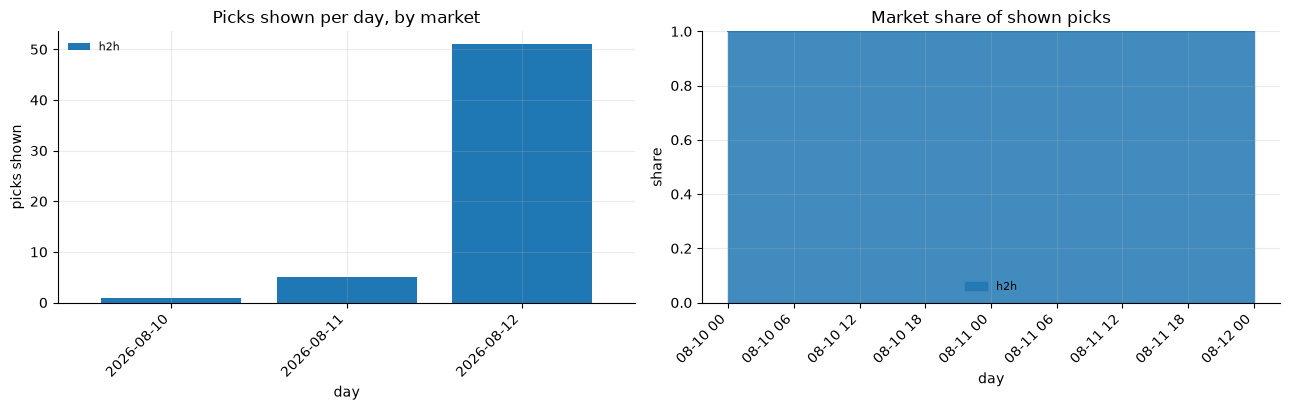

,n,mean_probability,priced
market,,,
h2h,57,0.708,21


In [14]:
if raw_snaps.empty:
    print("no pick snapshots yet")
else:
    snaps = raw_snaps.copy()
    snaps["day"] = pd.to_datetime(snaps["captured_at"], utc=True).dt.date
    mix = snaps.pivot_table(index="day", columns="market", values="id", aggfunc="count").fillna(0)
    share = mix.div(mix.sum(axis=1), axis=0)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
    mix.plot(kind="bar", stacked=True, ax=ax1, width=0.8)
    ax1.set_ylabel("picks shown")
    ax1.set_title("Picks shown per day, by market")
    ax1.legend(frameon=False, fontsize=8)
    share.plot(kind="area", stacked=True, ax=ax2, alpha=0.85)
    ax2.set_ylim(0, 1)
    ax2.set_ylabel("share")
    ax2.set_title("Market share of shown picks")
    ax2.legend(frameon=False, fontsize=8)
    for a in (ax1, ax2):
        plt.setp(a.get_xticklabels(), rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    display(snaps.groupby("market").agg(
        n=("id", "size"), mean_probability=("probability", "mean"),
        priced=("odds", lambda s: int(s.notna().sum()))).round(3))

## 9. Ad-hoc query

`history(...)` filters the loaded population and returns the individual calls plus the same
summary block used everywhere above — so a one-off question gets `n`, the interval and the
detectable effect attached to it automatically, rather than a bare percentage.

In [15]:
def history(sport=None, league=None, since=None, until=None, market=None,
            tier=None, min_prob=None, correct_only=None, kind=KIND, limit=50):
    '''Query the settled prediction history.

    Returns (rows, summary). The summary is deliberately not optional: a filtered accuracy is the
    easiest number in this project to over-read, and it is usually computed on a handful of rows.
    '''
    df = all_graded if INCLUDE_VOIDS else all_graded[all_graded["result_type"].isna()]
    df = df[df["kind"] == kind] if kind else df
    if sport:
        df = df[df["sport"] == sport]
    if league:
        df = df[df["league"] == league]
    if since:
        df = df[df["day"] >= pd.Timestamp(since).date()]
    if until:
        df = df[df["day"] <= pd.Timestamp(until).date()]
    if tier:
        df = df[df["confidence_tier"] == tier]
    if min_prob is not None:
        df = df[df["predicted_prob"] >= min_prob]
    if correct_only is not None:
        df = df[df["correct"] == int(bool(correct_only))]
    if market:
        print(f"note: market={market!r} ignored — graded rows are the 1X2 call. Per-market "
              "results come from pick_snapshots (section 7/8).")

    summary = summarise(df, "query")
    cols = ["day", "sport", "league", "home_team", "away_team", "predicted",
            "predicted_prob", "result", "correct", "confidence_tier",
            "feature_completeness", "model_version"]
    return df.sort_values("kickoff_utc", ascending=False)[cols].head(limit), summary


rows, summary = history()
print(summary)
display(rows.head(15))

{'population': 'query', 'n': 138, 'accuracy': 0.5217, 'ci_low': 0.4389, 'ci_high': 0.6034, 'baseline': np.float64(0.5145), 'gap_pp': np.float64(0.72), 'detectable_pp': 10.58, 'reportable': True, 'conclusive': False}


,day,sport,league,home_team,away_team,predicted,predicted_prob,result,correct,confidence_tier,feature_completeness,model_version
84,2026-08-12,tennis,atp,Brandon Nakashima,Rafael Jodar,home,0.561587,HOME_WIN,1,MEDIUM,0.785714,tennis_xgb_v20260801195314
266,2026-08-11,tennis,atp,Arthur Fils,Rafael Jodar,away,0.536082,AWAY_WIN,1,LOW,1.000000,tennis_xgb_v20260801195314
265,2026-08-11,tennis,atp,Luciano Darderi,Brandon Nakashima,home,0.561587,AWAY_WIN,0,MEDIUM,1.000000,tennis_xgb_v20260801195314
108,2026-08-11,tennis,atp,Shintaro Mochizuki,J.J. Wolf,home,0.815498,AWAY_WIN,0,HIGH,0.785714,tennis_xgb_v20260801195314
45,2026-08-10,football,liga_i,Sepsi OSK Sfantu Gheorghe,FCSB,home,0.474343,DRAW,0,LOW,0.258065,football_xgb_v20260810070503
154,2026-08-10,football,allsvenskan,Sirius,IF Brommapojkarna,home,0.482531,DRAW,0,LOW,0.258065,football_xgb_v20260810070503
155,2026-08-10,football,allsvenskan,Vasteras SK FK,Djurgardens IF,home,0.430518,HOME_WIN,1,LOW,0.258065,football_xgb_v20260810070503
44,2026-08-10,football,liga_i,FC Botosani,Corvinul Hunedoara,home,0.412543,DRAW,0,LOW,0.161290,football_xgb_v20260810070503
149,2026-08-09,football,brasileirao,Flamengo,Vitoria,home,0.463316,HOME_WIN,1,LOW,0.419355,football_xgb_v20260806213938
445,2026-08-09,tennis,atp,Ben Shelton,Joao Fonseca,home,0.642229,HOME_WIN,1,MEDIUM,0.928571,tennis_xgb_v20260801195314


In [16]:
# Examples — edit freely.
for label, kwargs in [
    ("football, high confidence", dict(sport="football", tier="HIGH")),
    ("tennis, model gave >=70%", dict(sport="tennis", min_prob=0.70)),
    ("last 3 days, all sports", dict(since=(pd.Timestamp.utcnow() - pd.Timedelta(days=3)).date())),
]:
    _, s = history(**kwargs)
    if s["n"]:
        print(f"{label:<28} n={s['n']:<4} acc={s['accuracy']:.3f} "
              f"CI[{s['ci_low']:.2f},{s['ci_high']:.2f}] vs base {s['baseline']:.3f} "
              f"({s['gap_pp']:+.1f}pp, detectable {s['detectable_pp']:.1f}pp)")
    else:
        print(f"{label:<28} no rows")

football, high confidence    n=4    acc=0.500 CI[0.15,0.85] vs base 0.750 (-25.0pp, detectable 62.2pp)
tennis, model gave >=70%     n=24   acc=0.583 CI[0.39,0.76] vs base 0.542 (+4.2pp, detectable 25.0pp)
last 3 days, all sports      n=8    acc=0.375 CI[0.14,0.69] vs base 0.375 (+0.0pp, detectable 42.6pp)


## 10. Retrodictions — inspect, never headline

A retrodiction is generated after the result is known. It belongs in the feed so a past card can
show what the model would have called, and it must never appear in a skill number. It is shown
here on its own so the difference is visible rather than assumed — retrodictions historically
score *worse*, because `assemble_from_game_log` carries a leakage guard and thinner features.

In [17]:
retro = all_graded[(all_graded["kind"] == "RETRODICTION") & (all_graded["result_type"].isna())]
pre = all_graded[(all_graded["kind"] == "PRE_MATCH") & (all_graded["result_type"].isna())]
unknown = all_graded[all_graded["kind"] == "UNKNOWN"]

comp = pd.DataFrame([
    summarise(pre, "PRE_MATCH (the only skill evidence)"),
    summarise(retro, "RETRODICTION (inspection only)"),
    summarise(unknown, "UNKNOWN provenance (excluded)"),
])
display(comp)
print("Mixing these was a real defect: /history/summary once averaged pre-match and retrodicted "
      "rows into one live, user-facing accuracy. Keeping them apart is the point of predictions.kind.")

,population,n,accuracy,ci_low,ci_high,baseline,gap_pp,detectable_pp,reportable,conclusive
0,PRE_MATCH (the only skill evidence),138,0.5217,0.4389,0.6034,0.5145,0.72,10.58,True,False
1,RETRODICTION (inspection only),0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,UNKNOWN provenance (excluded),591,0.5854,0.5453,0.6245,0.5245,6.09,5.04,True,False


Mixing these was a real defect: /history/summary once averaged pre-match and retrodicted rows into one live, user-facing accuracy. Keeping them apart is the point of predictions.kind.
